# Vietnam Festive & Retail Impact Analysis
**Objective:** Validate if Holidays and Retail Peaks (11.11, Tết...) significantly impact Revenue and COGS.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

sys.path.append(os.path.abspath('..'))
from src.config import Config
from src.data.holidays import get_vietnam_holidays

Config.initialize_dirs()
sns.set(style="whitegrid")

In [2]:
# Load data
sales = pd.read_parquet(Config.PROCESSED_DATA_DIR / "sales.parquet")
sales['Date'] = pd.to_datetime(sales['Date'])

# Get holidays logic
years = sales['Date'].dt.year.unique()
hol_df = get_vietnam_holidays(years)

# Merge
df = pd.merge(sales, hol_df, on='Date', how='left')
df['Holiday'] = df['Holiday'].fillna('None')
df['is_weekend'] = df['Date'].dt.dayofweek >= 5
df['day_type'] = np.where(df['Holiday'] != 'None', df['Holiday'], 
                 np.where(df['is_weekend'], 'Weekend', 'Normal'))

print("Sample distribution of day types:")
print(df['day_type'].value_counts())

Sample distribution of day types:
day_type
Normal               2653
Weekend              1063
Retail Peak            44
National Day           11
Mid-Autumn             11
Christmas              11
New Year               10
Tet                    10
Reunification Day      10
Labor Day              10
Name: count, dtype: int64


## 1 — Average Revenue by Day Type
Compare Holiday vs Weekend vs Normal days.

C:\Users\HP\AppData\Local\Temp\ipykernel_15784\3734944493.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_rev.index, y=avg_rev.values, palette='viridis')


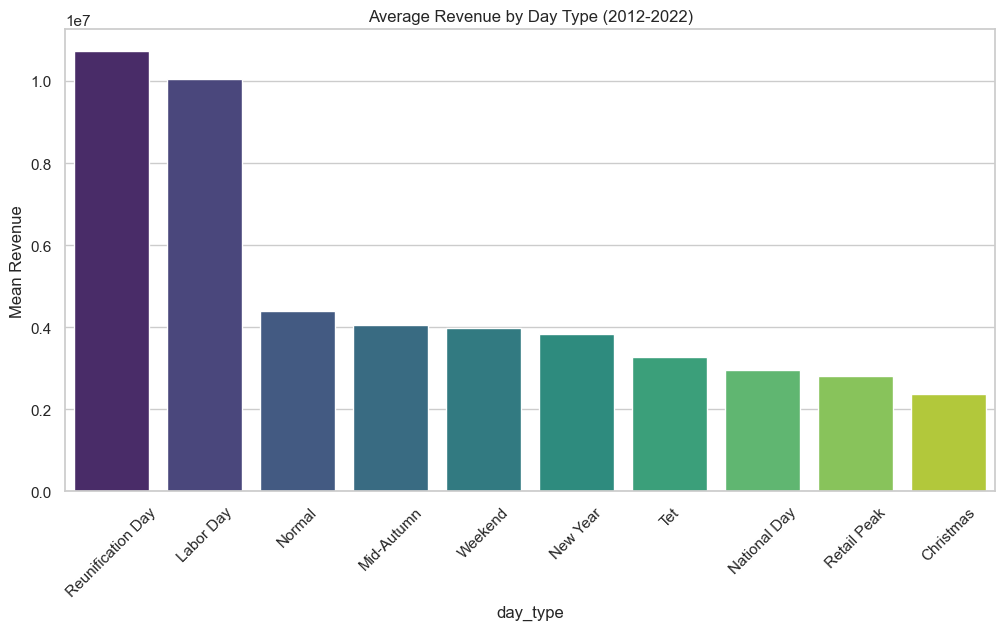

In [3]:
plt.figure(figsize=(12, 6))
avg_rev = df.groupby('day_type')['Revenue'].mean().sort_values(ascending=False)
sns.barplot(x=avg_rev.index, y=avg_rev.values, palette='viridis')
plt.title("Average Revenue by Day Type (2012-2022)")
plt.ylabel("Mean Revenue")
plt.xticks(rotation=45)
plt.show()

## 2 — The Tết Effect (Lunar New Year)
Zooming into the 30 days around Tết.

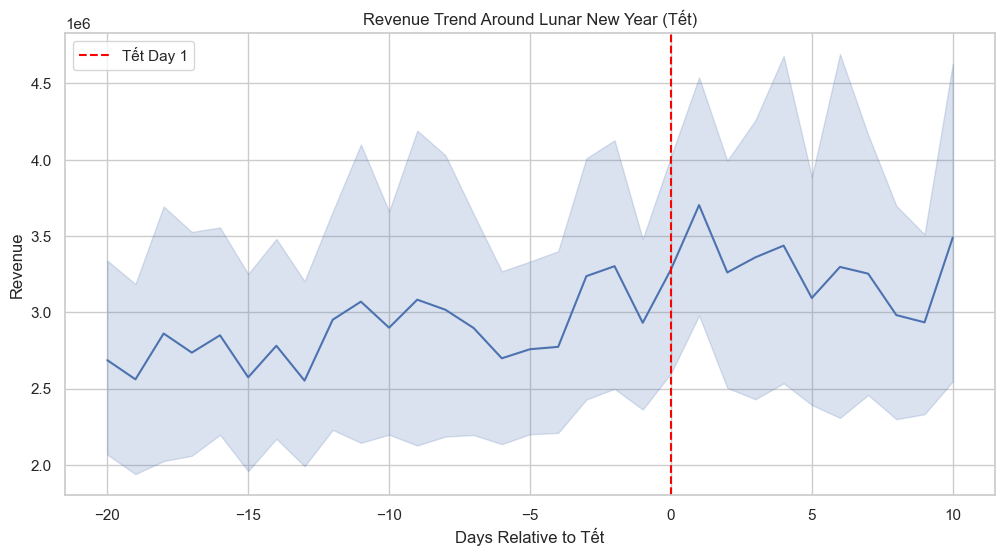

In [4]:
tet_dates = hol_df[hol_df['Holiday'] == 'Tet']['Date']
tet_data = []

for tet_d in tet_dates:
    start = tet_d - pd.Timedelta(days=20)
    end = tet_d + pd.Timedelta(days=10)
    mask = (df['Date'] >= start) & (df['Date'] <= end)
    subset = df[mask].copy()
    subset['days_rel_to_tet'] = (subset['Date'] - tet_d).dt.days
    tet_data.append(subset)

tet_combined = pd.concat(tet_data)

plt.figure(figsize=(12, 6))
sns.lineplot(data=tet_combined, x='days_rel_to_tet', y='Revenue', estimator='mean')
plt.axvline(0, color='red', linestyle='--', label='Tết Day 1')
plt.title("Revenue Trend Around Lunar New Year (Tết)")
plt.xlabel("Days Relative to Tết")
plt.legend()
plt.show()